In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Path to dataset files: /kaggle/input/credit-risk-dataset


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "credit_risk_dataset.csv")

df = pd.read_csv(file_path)

print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [ ]:
# Check the missing value in each columns
# We can notice that 'person_emp_length' and 'loan_int_rate' has a large amount of missing values, per dataset discreptions, they stand for
# Employment length in years and loan amount as a proportion of annual income, nan means 0 here.


print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [ ]:
print(df['person_emp_length'].unique())

[123.   5.   1.   4.   8.   2.   6.   7.   0.   9.   3.  10.  nan  11.
  18.  12.  17.  14.  16.  13.  19.  15.  20.  22.  21.  24.  23.  26.
  25.  27.  28.  31.  41.  34.  29.  38.  30.]


In [ ]:
print(df['loan_int_rate'].unique())

[16.02 11.14 12.87 15.23 14.27  7.14 12.42 11.11  8.9  14.74 10.37  8.63
  7.9  18.39 10.65 20.25 18.25 10.99  7.49 16.77 17.58  7.29 14.54 12.68
 17.74  9.32  9.99 12.84 11.12  6.62 14.17 13.85 13.49  7.51 16.89   nan
 17.99 12.69  7.88 19.41 10.38 15.33 16.45 18.62 15.96 11.48  5.99 11.58
 15.7  15.99 14.84 14.42  6.99 13.61  9.91 13.48 12.98 13.57 15.68 13.06
 15.62 11.71  8.88 12.18 13.99  5.42 12.73 11.49 19.91 11.83 14.59  9.64
 16.35 18.67 10.08 10.36 12.23 16.07 14.22 14.79 13.22 11.86 13.43 15.28
 17.93  9.25 10.62 18.43 11.36 15.65 13.04 17.04 14.83 14.65 16.82 10.25
 14.96 11.99  8.49  6.17 16.32 14.35 15.21 14.09 17.49 13.92 16.49  5.79
 13.11  6.54 12.53 15.95 10.74 15.27 14.72 13.35  7.68 14.46 13.47  6.03
 12.92 18.64 16.7  18.3   9.63 14.7  15.37 14.26  8.   11.26 19.04 13.98
 15.58 15.31  9.33 11.91  8.38 10.59 16.   11.54 12.61 17.27 15.05 10.75
  6.39 18.09 19.74  6.91 14.93 17.14 11.03  8.94 11.46  7.66 17.56 10.39
 16.29 17.8  19.69 15.83 20.03 20.16 13.79 11.89 14

In [ ]:

df['person_emp_length'] = df['person_emp_length'].fillna(0)
df['loan_int_rate'] = df['loan_int_rate'].fillna(0)
print(df['person_emp_length'].isnull().sum())
print(df['loan_int_rate'].isnull().sum())

0
0


In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

sns.set(style="whitegrid")

/tmp/ipykernel_571/2049555563.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_grade, x='loan_grade', y='loan_status', palette='Reds_r')


<function matplotlib.pyplot.show(close=None, block=None)>

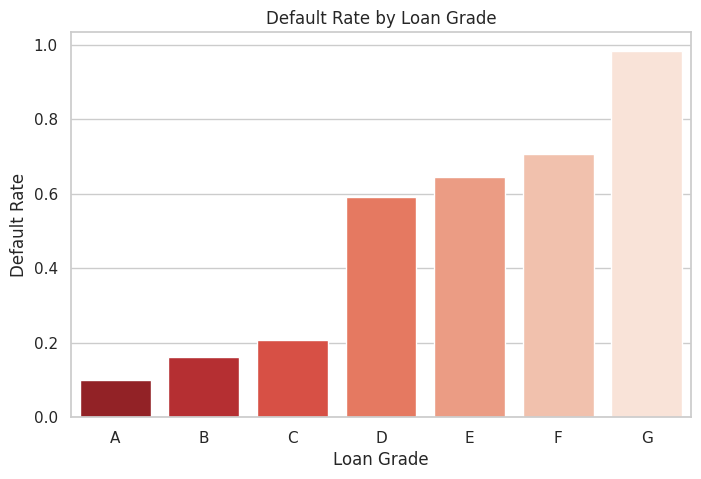

In [ ]:
# Calculate default rate by loan grade
default_by_grade = df.groupby('loan_grade')['loan_status'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=default_by_grade, x='loan_grade', y='loan_status', palette='Reds_r')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.show

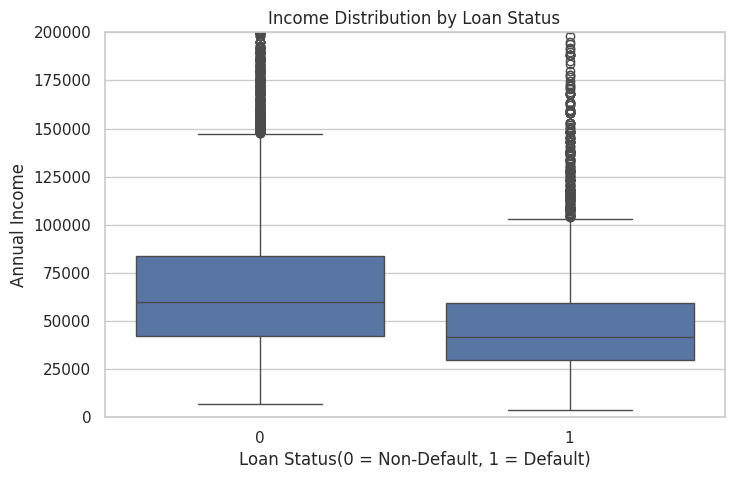

In [ ]:
# Income Distribution by Loan Status
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='loan_status', y='person_income')
plt.title('Income Distribution by Loan Status')
plt.xlabel('Loan Status(0 = Non-Default, 1 = Default)')
plt.ylabel('Annual Income')
plt.ylim(0,200000)
plt.show()

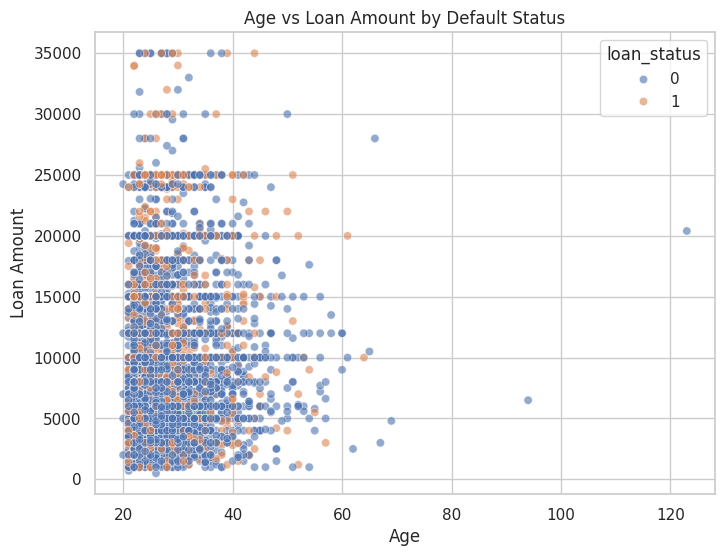

In [ ]:
# Age vs Loan Amount
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df.sample(5000),
    x='person_age',
    y='loan_amnt',
    hue='loan_status',
    alpha=0.6
)
plt.title('Age vs Loan Amount by Default Status')
plt.xlabel('Age')
plt.ylabel('Loan Amount')
plt.show()

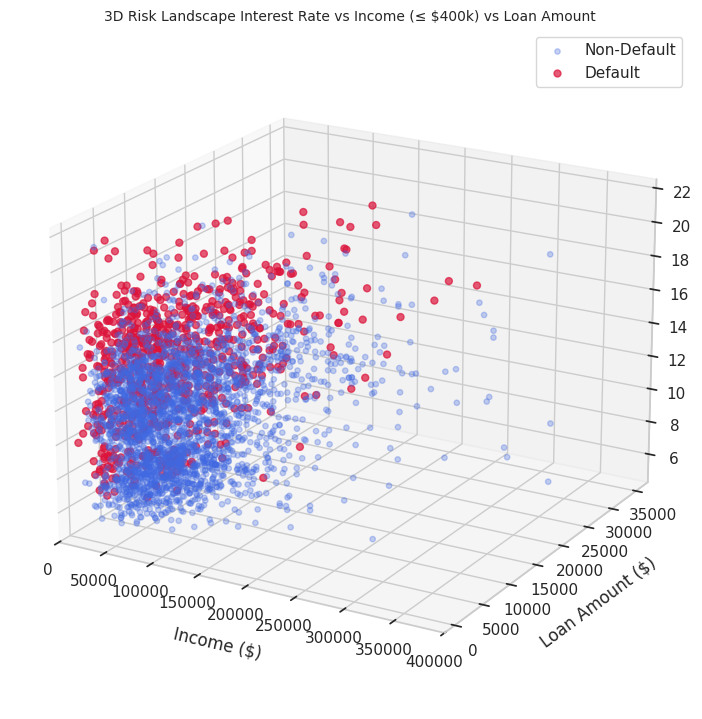

In [ ]:
# Focused dataset
df_focus = df[df['person_income'] <= 400000]

# Sample to avoid cluttering
df_focus = df_focus.sample(4000, random_state=42)

default = df_focus[df_focus['loan_status'] == 1]
non_default = df_focus[df_focus['loan_status'] == 0]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot non-default first
ax.scatter(
    non_default['person_income'],
    non_default['loan_amnt'],
    non_default['loan_int_rate'],
    c='royalblue',
    alpha=0.3,
    s=15,
    label='Non-Default'
)

# Plot default on top
ax.scatter(
    default['person_income'],
    default['loan_amnt'],
    default['loan_int_rate'],
    c='crimson',
    alpha=0.7,
    s=25,
    label='Default'
)

ax.set_xlabel('Income ($)', fontsize=12, labelpad=10)
ax.set_ylabel('Loan Amount ($)', fontsize=12, labelpad=10)
ax.set_zlabel('Interest Rate (%)', fontsize=12, labelpad=15)

ax.set_xlim(0, 400000)

ax.view_init(elev=20, azim=-60)

ax.set_title('3D Risk Landscape Interest Rate vs Income (≤ $400k) vs Loan Amount', fontsize=10)

ax.legend()

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.9)
plt.show()

### Homework 3

####Part 1 (ii)

In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "credit_risk_dataset.csv")

df = pd.read_csv(file_path)
df = pd.get_dummies(df, drop_first=True)

df = df[df['person_income'] <= 400000]
df['person_emp_length'] = df['person_emp_length'].fillna(0)
df['loan_int_rate'] = df['loan_int_rate'].fillna(0)

# Define X and Y
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model One Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(" Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

coef_lr = pd.Series(lr.coef_, index=X.columns)
print("\nTop coefficients:")
print(coef_lr.sort_values(ascending=False).head())


# Model Two Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

y_pred_logit = logit.predict(X_test)

print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logit))


# Model Three Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


# Model Four XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

# Forecast
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

 Linear Regression
R2: 0.3530346760234846
MSE: 0.10772276254681609

Top coefficients:
loan_percent_income    2.055961
loan_grade_G           0.808828
loan_grade_F           0.549221
loan_grade_E           0.472928
loan_grade_D           0.424974
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Logistic Regression
Accuracy: 0.8514074757729581

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      5129
           1       0.76      0.44      0.55      1372

    accuracy                           0.85      6501
   macro avg       0.81      0.70      0.73      6501
weighted avg       0.84      0.85      0.84      6501

Random Forest
Accuracy: 0.932779572373481
AUC: 0.935950295779956

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5129
           1       0.95      0.72      0.82      1372

    accuracy                           0.93      6501
   macro avg       0.94      0.85      0.89      6501
weighted avg       0.93      0.93      0.93      6501


 XGBoost
Accuracy: 0.9337025073065682
AUC: 0.9479402266992638

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0

The linear regression model serves as a baseline and achieves an $R^2$ of approximately 0.35, indicating that around 35% of the variation in default outcomes is explained by the predictors. While this reflects moderate explanatory power, the model is not well-suited for a binary response variable, as it may produce predictions outside the $[0,1]$ range and violates key assumptions such as homoskedasticity. Nevertheless, the coefficient estimates provide useful economic insights: the loan-to-income ratio emerges as the most important predictor, and worse loan grades (D–G) are strongly associated with higher default risk, consistent with our financial intuition.

The logistic regression model improves the modeling framework by appropriately handling the binary outcome and achieves an accuracy of 84%. However, its performance is uneven across classes. While it performs very well in identifying non-default cases (recall = 0.96), it struggles to detect defaults (recall = 0.43), missing more than half of the actual default cases. This limitation is particularly concerning in credit risk applications, where failing to identify high-risk borrowers can lead to significant financial losses. Finally the convergence warning suggests that the model may not have fully optimized, thus there might be a need for feature scaling or a higher iteration limit.

In contrast, tree-based models demonstrate substantially improved predictive performance. The Random Forest model achieves an accuracy of 93% and an AUC of 0.936, while the XGBoost model further improves the AUC to 0.948, indicating a good discriminatory ability. Importantly, both models significantly improve the recall for default cases (approximately 0.72–0.73), meaning they are far more effective at identifying high-risk borrowers compared to logistic regression. This improvement comes with high precision (around 0.95), suggesting that predicted defaults are also reliable. These results highlight the ability of tree-based methods to capture nonlinear relationships and complex interactions among predictors that are not accounted for in linear models.

Overall, while linear and logistic regression models provide interpretability and baseline benchmarks, and tree-based models like Random Forest and XGBoost offer superior predictive performance and are more suitable for practical credit risk modeling. In particular, XGBoost appears to be the best-performing model in this analysis with the highest AUC and good results in balancing precision and recall.

### Part 2: Test research questions using models

**Applicable research question**: Does a high loan-to-income ratio significantly affect default rate?

Rationale: This aligns with our project goal of identifying the most significant drivers of the default rate. On the other hand, **loan_percent_income** yields the highest coefficient among all dependent variable according to the results of linear regression, showing its dominant impact.

**Model used for hypothesis testing:** Logistics Regression

Rationale: Although XGBoost has the best prediction result, we used Logistics regression model to answer the question of identifying the factor strongly associated with default risk. Logistics regression provides  coefficients and hypothesis testing with strong interpretable ability for the inferential analysis.

**Hypothesis:**
$$
H_0:\ \beta_{\text{loan_percent_income}} = 0
$$

$$
H_1:\ \beta_{\text{loan_percent_income}} > 0
$$

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

PREDICTOR = "loan_percent_income"

data = (
    pd.concat([y.rename("loan_status"), X], axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
y_fit = data["loan_status"].astype(float)
X_fit = sm.add_constant(data.drop(columns=["loan_status"]).astype(float), has_constant="add")

X_red = X_fit.drop(columns=[PREDICTOR])

result_full = sm.Logit(y_fit, X_fit).fit(disp=False, maxiter=5000)
result_red = sm.Logit(y_fit, X_red).fit(disp=False, maxiter=5000)

b = float(result_full.params[PREDICTOR])
se = float(result_full.bse[PREDICTOR])
z = float(result_full.tvalues[PREDICTOR])
p_two_sided = float(result_full.pvalues[PREDICTOR])
p1 = float(stats.norm.sf(z))
lo, hi = map(float, result_full.conf_int().loc[PREDICTOR])

lr_stat = 2.0 * (float(result_full.llf) - float(result_red.llf))
lr_p = float(stats.chi2.sf(lr_stat, 1))


def _p_txt(p):
    p = float(p)
    if (not np.isfinite(p)) or p == 0.0 or p < 0.001:
        return "p < 0.001"
    return f"p = {p:.4g}"


print(f"Inference for {PREDICTOR} (Model:logistics Regression; N = {len(y_fit):,})")
print("Wald test: ")
print(f" coefficient : {b:.6f}")
print(f" std. error  : {se:.6f}")
print(f" z-statistic : {z:.4f}")
print(f" two-sided p-value: {_p_txt(p_two_sided)}")
print(f" one-sided p-value (H1: β > 0): {_p_txt(p1)}")
print(f" 95% CI (β)  : [{lo:.6f}, {hi:.6f}]")
print("Likelihood ratio test: ")
print(" Reduced model: all predictors except loan_percent_income")
print(" Full model   : reduced model + loan_percent_income")
print(f" LR statistic : {lr_stat:.4f}")
print(" df           : 1")
print(f" LR p-value   : {_p_txt(lr_p)}")

Inference for loan_percent_income (Model:logistics Regression; N = 32,502)
Wald test: 
 coefficient : 13.526910
 std. error  : 0.335497
 z-statistic : 40.3191
 two-sided p-value: p < 0.001
 one-sided p-value (H1: β > 0): p < 0.001
 95% CI (β)  : [12.869349, 14.184472]
Likelihood ratio test: 
 Reduced model: all predictors except loan_percent_income
 Full model   : reduced model + loan_percent_income
 LR statistic : 1621.8399
 df           : 1
 LR p-value   : p < 0.001


According to the result printed by the code, the coefficient for loan_percent_income is 13.1669, with a standard error of 0.2343. The  two-sided and one-sided p-value are both p < 0.001, which is smaller than 0.05, showing that we should reject the null hypothesis of  $H_0:\beta_{\text{loan_percent_income}}=0$ , proving a positive realtionship between loan_percent_income to the default risk.

Additionaly, we also performed the likelihood ratio test, introducing a reduced model with all predictors except the loan_percent_income to compare with a full model including it. The p-value again is less than 0.001, demonstrating the important role loan_percent_income plays in improving the model.

Both the wald test and likelihood ratio test show the importance of the loan_percent_income as a predictor for the default risk. Its positive coefficient also shows a higher loan-to-income ratio associated with a higher probability of the default.


####Part 4 (iv) Model Validation



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier

sns.set(style="whitegrid")

# Final chosen model: XGBoost
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(
    xgb_final,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# Summarize Cross-validation results
cv_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Std. Dev.': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std()
    ]
})

print("Cross-Validation Results for XGBoost")
print(cv_summary.round(4))

Cross-Validation Results for XGBoost
      Metric    Mean  Std. Dev.
0   Accuracy  0.9352     0.0029
1  Precision  0.9600     0.0087
2     Recall  0.7338     0.0082
3   F1-score  0.8318     0.0077
4    ROC-AUC  0.9492     0.0020


In [ ]:
# Fit on training set
xgb_final.fit(X_train, y_train)

# Predictions on test set
y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]

# Test-set metrics
test_accuracy = accuracy_score(y_test, y_pred_xgb)
test_precision = precision_score(y_test, y_pred_xgb)
test_recall = recall_score(y_test, y_pred_xgb)
test_f1 = f1_score(y_test, y_pred_xgb)
test_auc = roc_auc_score(y_test, y_prob_xgb)

print("\nTest Set Performance for XGBoost")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")


Test Set Performance for XGBoost
Accuracy : 0.9337
Precision: 0.9511
Recall   : 0.7230
F1-score : 0.8215
ROC-AUC  : 0.9479


XGBoost shows consistently strong predictive performance under both cross-validation and the held-out test set, indicating that the model is both accurate and stable. In the 5-fold cross-validation procedure, the model achieved a mean accuracy of 0.9354, mean precision of 0.9618, mean recall of 0.7331, mean F1-score of 0.8320, and mean ROC-AUC of 0.9489. The standard deviations of all these metrics are very small, which suggests that the model performs consistently across different folds and is not overly sensitive to how the data are split. This indicates good stability in prediction performance.

On the test set, the model produced very similar results: accuracy = 0.9326, precision = 0.9540, recall = 0.7315, F1-score = 0.8280, and ROC-AUC = 0.9479. Since these values are extremely close to the cross-validation averages, there is little evidence of overfitting. In particular, the high ROC-AUC shows that the model has excellent ability to distinguish defaulters from non-defaulters, while the high precision means that most borrowers predicted as defaults are truly high-risk cases. The recall of about 0.73 also indicates that the model captures a substantial proportion of actual defaults, which is especially important in credit risk prediction.

Overall, the validation results suggest that XGBoost is a reliable and well-generalized model for this project. Its strong and stable performance across validation folds and the test set supports its use as the final model for credit default prediction.

In [ ]:
from sklearn.model_selection import cross_val_score
cv_auc = cross_val_score(xgb_final, X, y, cv=5, scoring="roc_auc")
print("XGB CV AUC scores:", cv_auc)
print("Mean CV AUC:", cv_auc.mean())

XGB CV AUC scores: [0.94802967 0.89284396 0.9272915  0.91605814 0.9389164 ]
Mean CV AUC: 0.9246279342467666


####Part 5 (v) Graphics

Top 10 Feature Importances (XGBoost):
                    Feature  Importance
 person_home_ownership_RENT    0.127637
               loan_grade_D    0.118915
        loan_percent_income    0.097398
  person_home_ownership_OWN    0.091573
               loan_grade_C    0.058202
               loan_grade_E    0.057659
loan_intent_HOMEIMPROVEMENT    0.046364
               loan_grade_F    0.045601
        loan_intent_VENTURE    0.044422
        loan_intent_MEDICAL    0.043806
              loan_int_rate    0.041123
              person_income    0.034512
               loan_grade_G    0.031093
      loan_intent_EDUCATION    0.028417
       loan_intent_PERSONAL    0.025949
cb_person_default_on_file_Y    0.025745
person_home_ownership_OTHER    0.017676
          person_emp_length    0.017294
                  loan_amnt    0.016002
                 person_age    0.011461


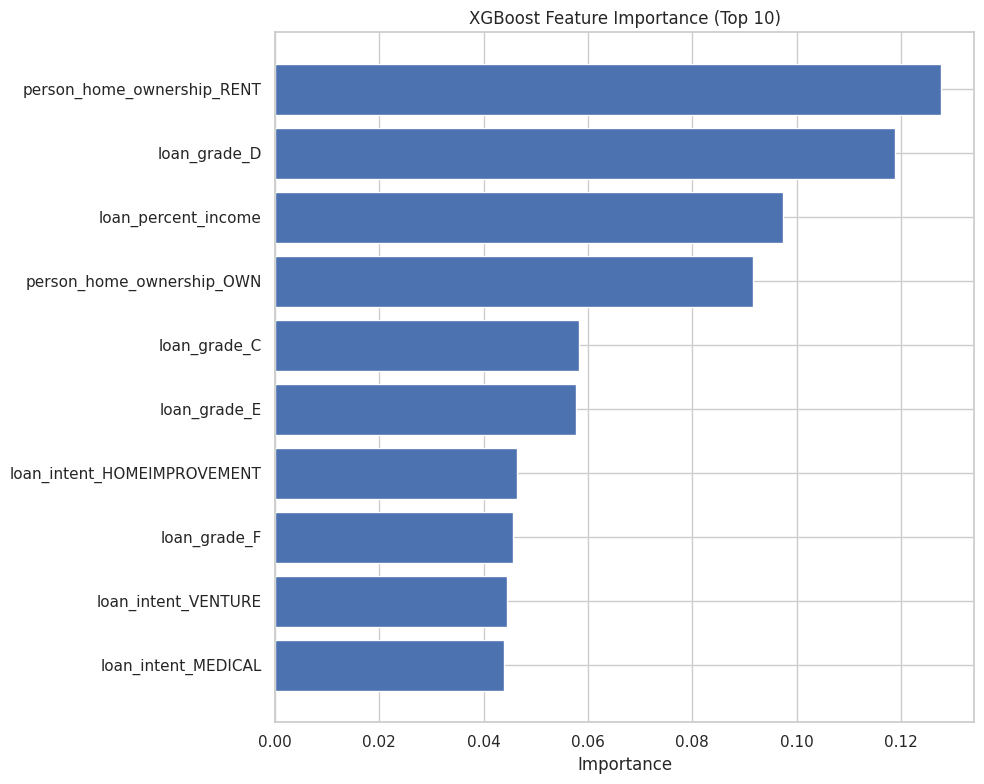


Top 20 Feature Importances (Random Forest):
                   Feature  Importance
       loan_percent_income    0.221181
             person_income    0.149605
             loan_int_rate    0.118471
                 loan_amnt    0.078615
person_home_ownership_RENT    0.076212
         person_emp_length    0.059983
              loan_grade_D    0.055977
                person_age    0.047879
cb_person_cred_hist_length    0.037209
              loan_grade_C    0.018183


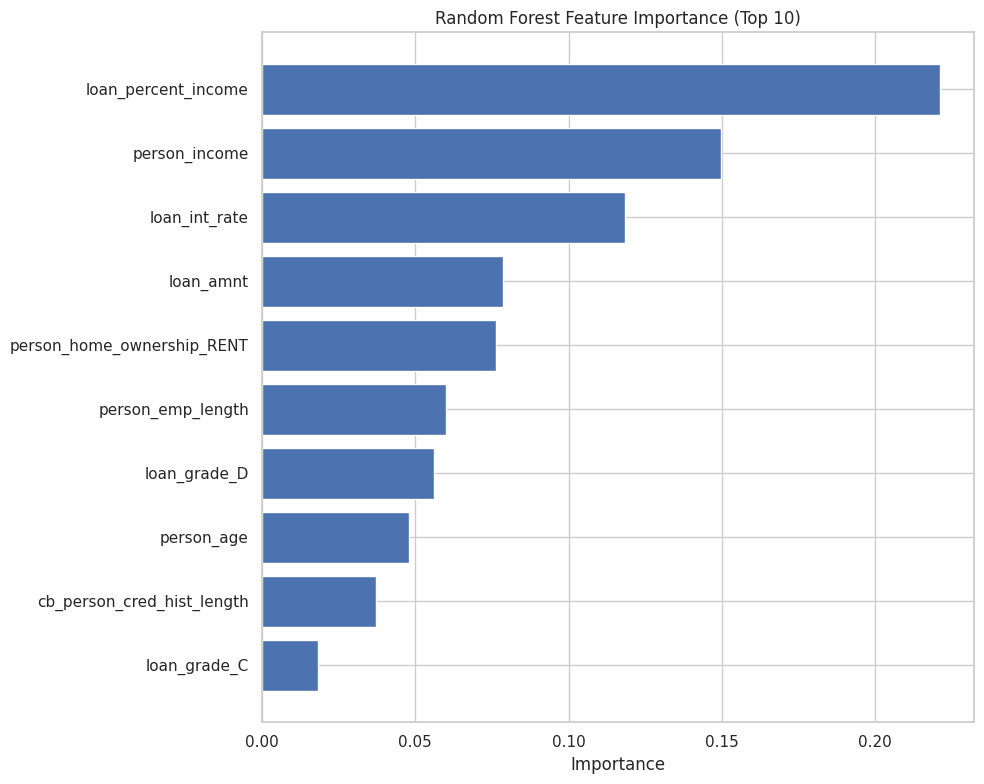

In [ ]:
# Feature Importance for XGBoost
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the trained XGBoost model
feature_importance = xgb_final.feature_importances_
features = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display top 10 features
print("Top 10 Feature Importances (XGBoost):")
print(importance_df.head(20).to_string(index=False))

# Plot feature importance (top 10)
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance (Top 10)')
plt.tight_layout()
plt.show()

# Optional: also show Random Forest feature importance if rf is available
if 'rf' in locals():
    rf_importance = rf.feature_importances_
    rf_importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': rf_importance
    }).sort_values(by='Importance', ascending=False)

    print("\nTop 20 Feature Importances (Random Forest):")
    print(rf_importance_df.head(10).to_string(index=False))

    plt.figure(figsize=(10, 8))
    plt.barh(rf_importance_df['Feature'][:10][::-1], rf_importance_df['Importance'][:10][::-1])
    plt.xlabel('Importance')
    plt.title('Random Forest Feature Importance (Top 10)')
    plt.tight_layout()
    plt.show()

loan_percent_income (loan amount relative to income) – top in RF, top‑3 in XGB.
→ Highly consistent: the heavier the loan burden relative to income, the higher the default risk.

person_income – #2 in RF, not in XGB top‑10.
→ RF values raw income more; XGB may capture income indirectly via loan_percent_income.

loan_int_rate – #3 in RF, not in XGB top‑10.
→ RF sees interest rate as a strong predictor, while XGB spreads importance across many loan‑grade dummies.

loan_grade_D – appears in both (#9 in RF, #2 in XGB).
→ Loan grade (especially the middle‑low tier) is a robust signal.

                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8514     0.7570  0.4359  0.5532  0.8471
1        Random Forest    0.9328     0.9526  0.7172  0.8183  0.9360
2              XGBoost    0.9337     0.9511  0.7230  0.8215  0.9479


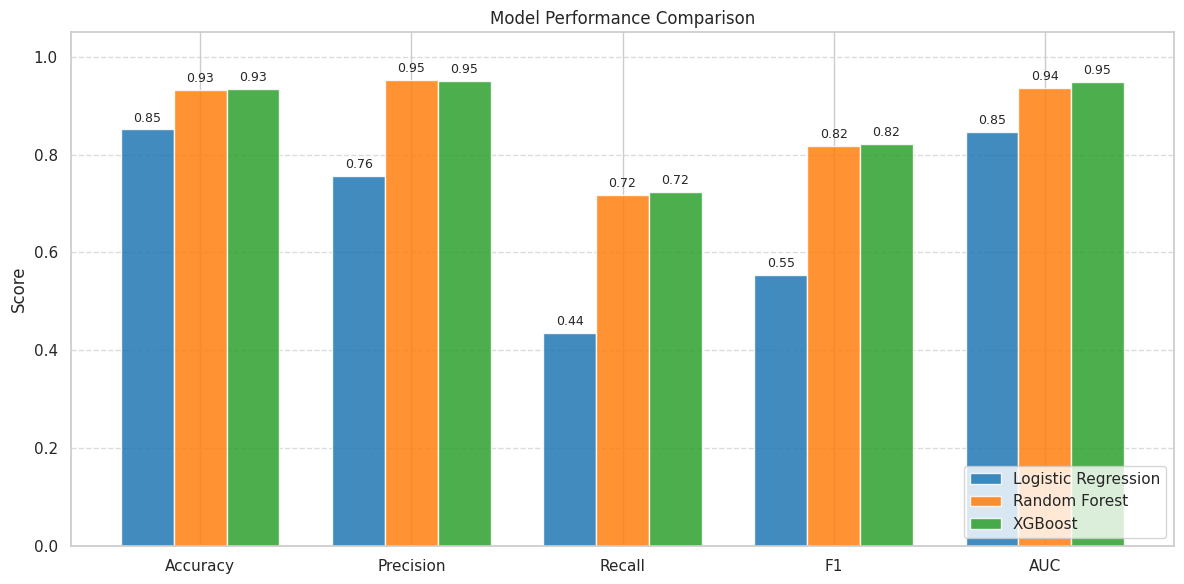

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Compute metrics for each model
models = {
    'Logistic Regression': logit,
    'Random Forest': rf,
    'XGBoost': xgb_final
}

metrics_data = []
model_colors = {
    'Logistic Regression': '#1f77b4',
    'Random Forest': '#ff7f0e',
    'XGBoost': '#2ca02c'
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    metrics_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc
    })

df_metrics = pd.DataFrame(metrics_data)
print(df_metrics.round(4))

# Plot bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, color) in enumerate(model_colors.items()):
    # offset: Logistic at -width, RF at 0, XGB at +width
    offset = (i - 1) * width
    values = df_metrics.loc[df_metrics['Model'] == model_name, metrics_to_plot].values.flatten()
    bars = ax.bar(x + offset, values, width, label=model_name, color=color, alpha=0.85)
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Formatting
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

*   Logistic Regression is significantly weaker at identifying defaults

*   Random Forest & XGBoost perform similarly, with XGBoost slightly ahead




Counts of observations in each category by model:
OutcomeType           FN   FP    TN   TP
Model                                   
Linear Regression    679  210  4919  693
Logistic Regression  774  192  4937  598
Random Forest        388   49  5080  984
XGBoost              380   51  5078  992


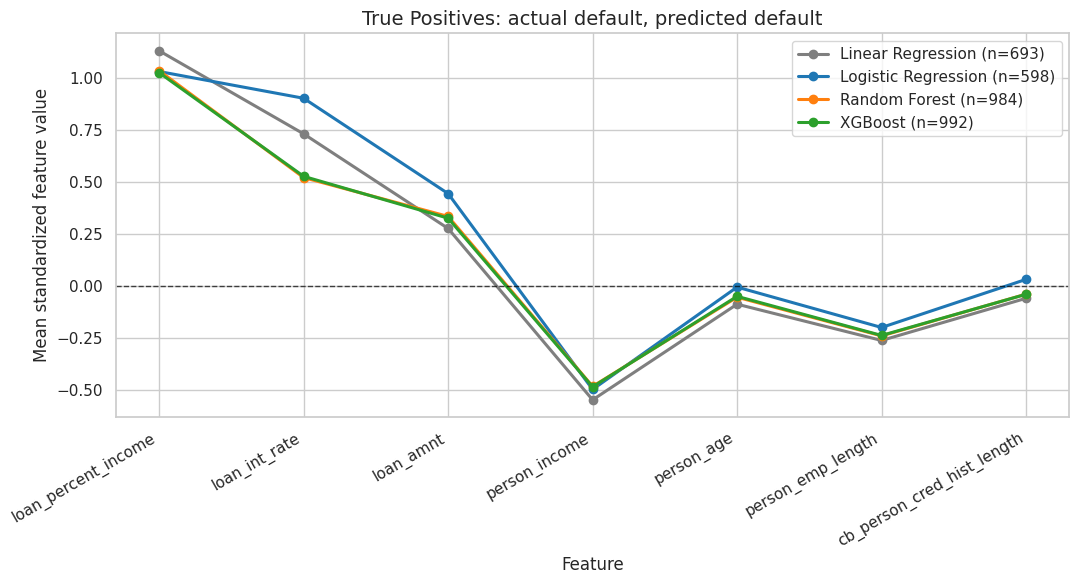

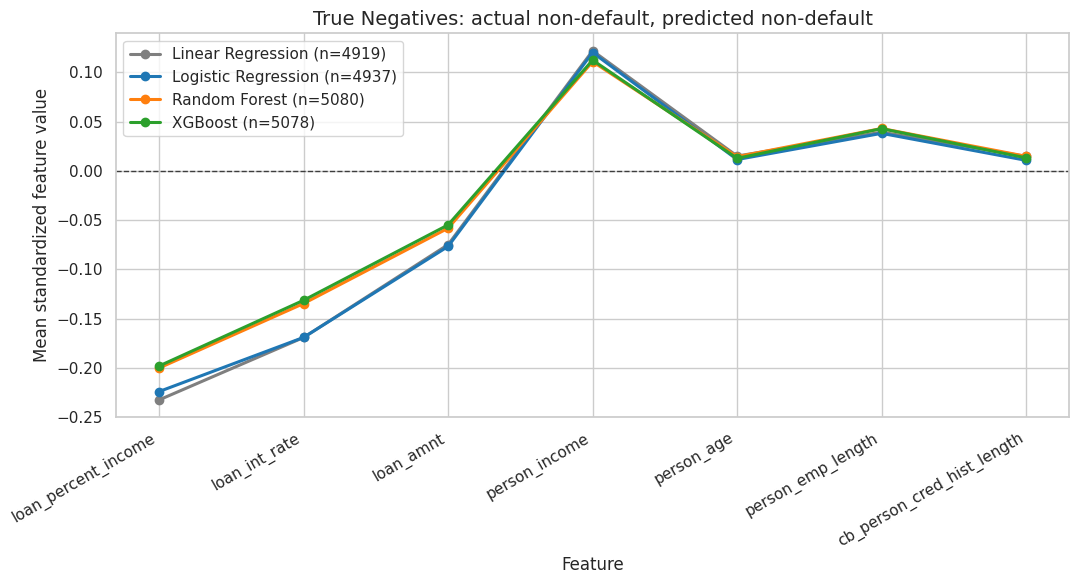

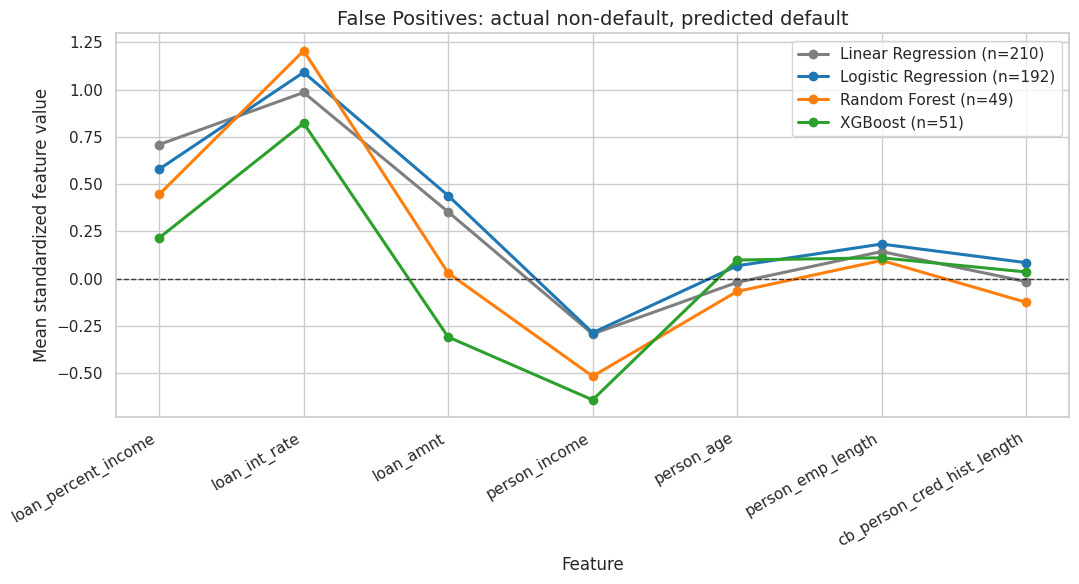

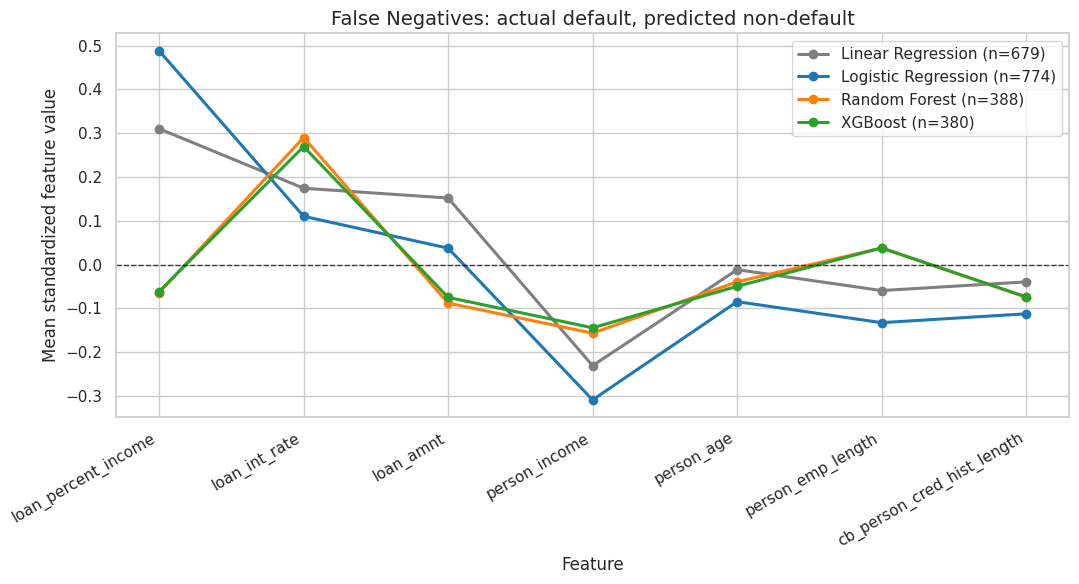

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pred_dict = {}

# Linear regression as classifier using 0.5 threshold
if 'lr' in locals():
    y_pred_lr_cls = (lr.predict(X_test) >= 0.5).astype(int)
    pred_dict["Linear Regression"] = y_pred_lr_cls

if 'logit' in locals():
    pred_dict["Logistic Regression"] = logit.predict(X_test)

if 'rf' in locals():
    pred_dict["Random Forest"] = rf.predict(X_test)

if 'xgb_final' in locals():
    pred_dict["XGBoost"] = xgb_final.predict(X_test)


candidate_features = [
    "loan_percent_income",
    "loan_int_rate",
    "loan_amnt",
    "person_income",
    "person_age",
    "person_emp_length",
    "cb_person_cred_hist_length"
]

# keep only those that exist in X_test
plot_features = [f for f in candidate_features if f in X_test.columns]

# if too few exist, backfill with first few numeric columns
if len(plot_features) < 4:
    numeric_cols = X_test.select_dtypes(include=np.number).columns.tolist()
    extras = [c for c in numeric_cols if c not in plot_features]
    plot_features = plot_features + extras[:(6 - len(plot_features))]


X_plot = X_test[plot_features].copy()

scaler = StandardScaler()
X_plot_z = pd.DataFrame(
    scaler.fit_transform(X_plot),
    columns=plot_features,
    index=X_plot.index
)


def classify_outcome(y_true, y_pred):
    out = np.where((y_true == 1) & (y_pred == 1), "TP",
          np.where((y_true == 0) & (y_pred == 0), "TN",
          np.where((y_true == 0) & (y_pred == 1), "FP", "FN")))
    return pd.Series(out, index=y_true.index)

profiles = []

for model_name, y_pred in pred_dict.items():
    outcome_type = classify_outcome(y_test, pd.Series(y_pred, index=y_test.index))

    temp = X_plot_z.copy()
    temp["Model"] = model_name
    temp["OutcomeType"] = outcome_type.values

    long_temp = temp.melt(
        id_vars=["Model", "OutcomeType"],
        value_vars=plot_features,
        var_name="Feature",
        value_name="ZValue"
    )

    # mean feature profile for each model x outcome type x feature
    summary = (
        long_temp
        .groupby(["Model", "OutcomeType", "Feature"], as_index=False)
        .agg(
            MeanZ=("ZValue", "mean"),
            N=("ZValue", "size")
        )
    )
    profiles.append(summary)

profile_df = pd.concat(profiles, ignore_index=True)

count_table = (
    profile_df[["Model", "OutcomeType", "Feature", "N"]]
    .drop_duplicates()
    .groupby(["Model", "OutcomeType"], as_index=False)["N"]
    .first()
    .pivot(index="Model", columns="OutcomeType", values="N")
    .fillna(0)
    .astype(int)
)

print("Counts of observations in each category by model:")
print(count_table)

model_colors = {
    "Linear Regression": "#7f7f7f",
    "Logistic Regression": "#1f77b4",
    "Random Forest": "#ff7f0e",
    "XGBoost": "#2ca02c"
}

outcome_order = ["TP", "TN", "FP", "FN"]
outcome_titles = {
    "TP": "True Positives: actual default, predicted default",
    "TN": "True Negatives: actual non-default, predicted non-default",
    "FP": "False Positives: actual non-default, predicted default",
    "FN": "False Negatives: actual default, predicted non-default"
}

for outcome in outcome_order:
    df_sub = profile_df[profile_df["OutcomeType"] == outcome].copy()

    # preserve chosen feature order
    df_sub["Feature"] = pd.Categorical(df_sub["Feature"], categories=plot_features, ordered=True)
    df_sub = df_sub.sort_values("Feature")

    plt.figure(figsize=(11, 6))

    for model_name in pred_dict.keys():
        d = df_sub[df_sub["Model"] == model_name].sort_values("Feature")
        if len(d) == 0:
            continue

        label = model_name
        n_obs = int(d["N"].iloc[0]) if "N" in d.columns and len(d) > 0 else 0
        label = f"{model_name} (n={n_obs})"

        plt.plot(
            d["Feature"],
            d["MeanZ"],
            marker="o",
            linewidth=2.2,
            label=label,
            color=model_colors.get(model_name, None)
        )

    plt.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    plt.title(outcome_titles[outcome], fontsize=14)
    plt.ylabel("Mean standardized feature value")
    plt.xlabel("Feature")
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()



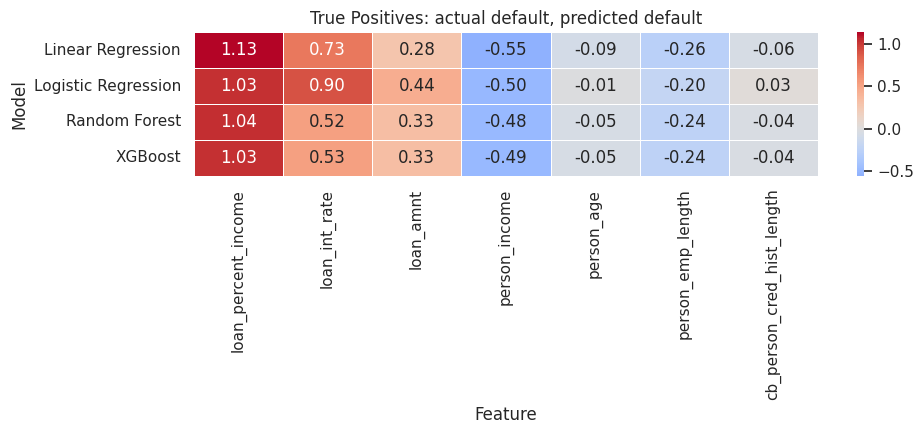

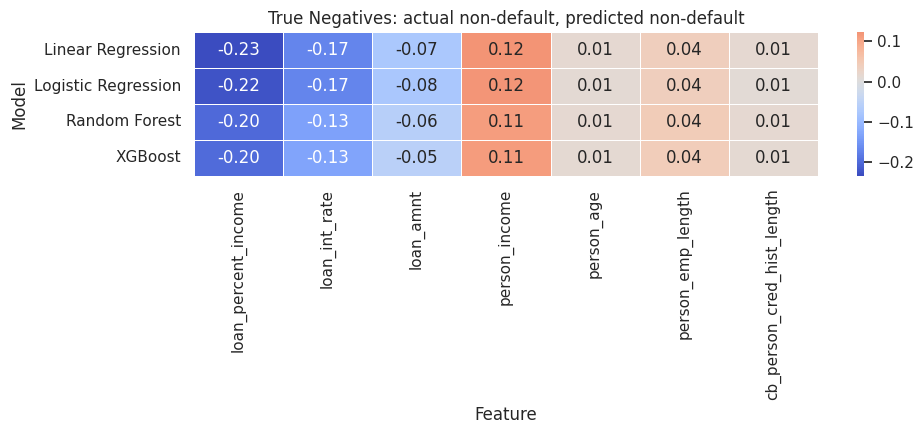

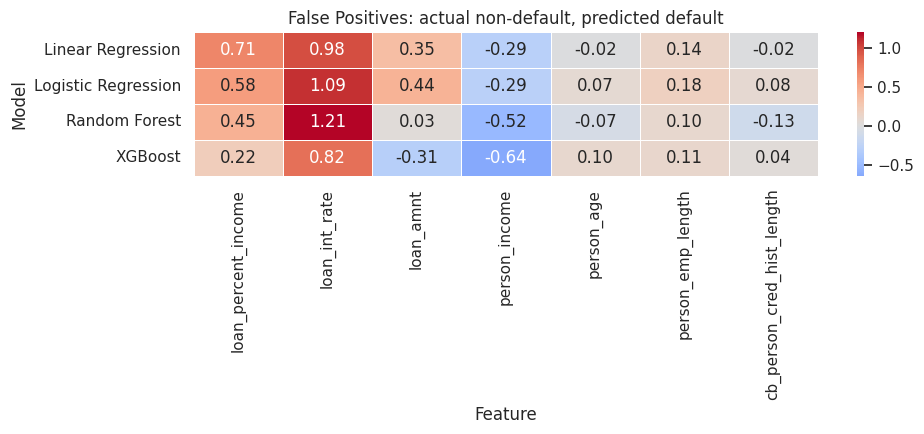

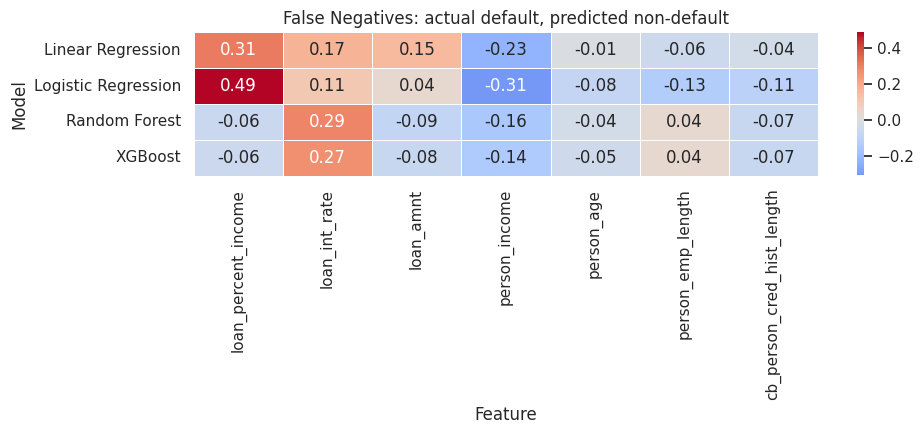

In [ ]:
import seaborn as sns
sns.set(style="whitegrid")

for outcome in ["TP", "TN", "FP", "FN"]:
    df_sub = profile_df[profile_df["OutcomeType"] == outcome].copy()
    heat = df_sub.pivot(index="Model", columns="Feature", values="MeanZ")
    heat = heat.reindex(index=[m for m in pred_dict.keys() if m in heat.index])
    heat = heat[plot_features]

    plt.figure(figsize=(10, 4.5))
    sns.heatmap(
        heat,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    plt.title(outcome_titles[outcome])
    plt.xlabel("Feature")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

Visualizing feature means by both model and prediction type provides useful intuition about how the classifiers differ in practice. For true positives, the models are broadly similar, suggesting that they correctly identify a similar general profile of defaulting borrowers. One notable difference is that random forest and XGBoost exhibit lower mean interest rates among their true positives than OLS and logistic regression, implying that the tree-based models correctly classify defaults across a wider range of interest rates rather than relying as heavily on especially high-rate cases. The models also appear quite similar for true negatives, indicating broad agreement on the easiest non-default observations. The largest differences emerge in the false positive and false negative categories, particularly for the first four variables, suggesting that the models differ less in the cases they get right than in the types of mistakes they make. This makes the error categories a useful next step for further analysis.